# ***Домашняя работа №8-09***
## Еськина Ева
### БФБО-03-24

### ***2.3.1. Импорты, seed и устройство***

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import json
from pathlib import Path
import random
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Фиксируем seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Определяем устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# Создаем структуру папок
ARTIFACTS_DIR = Path('artifacts')
FIGURES_DIR = ARTIFACTS_DIR / 'figures'
ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

Используемое устройство: cpu


### ***2.3.2. Данные и DataLoader***

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Нормализация для grayscale
])

# Загружаем EMNIST Balanced
train_dataset = torchvision.datasets.EMNIST(
    root='./data', 
    split='balanced',
    train=True, 
    download=True, 
    transform=transform
)

test_dataset = torchvision.datasets.EMNIST(
    root='./data', 
    split='balanced',
    train=False, 
    download=True, 
    transform=transform
)

100.0%


In [3]:
# Разбиение train на train/val (80/20)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

# Используем фиксированный seed для воспроизводимого разбиения
generator = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(
    train_dataset, 
    [train_size, val_size],
    generator=generator
)

print(f"Размер train: {len(train_subset)}")
print(f"Размер val: {len(val_subset)}")
print(f"Размер test: {len(test_dataset)}")
print(f"Количество классов: {len(train_dataset.classes)}")

Размер train: 90240
Размер val: 22560
Размер test: 18800
Количество классов: 47


In [4]:
# Создаем DataLoader'ы
batch_size = 128
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Sanity check
x, y = next(iter(train_loader))
print(f"\nSanity check:")
print(f"Batch x shape: {x.shape}")
print(f"Batch y shape: {y.shape}")
print(f"x min: {x.min():.3f}, x max: {x.max():.3f}")
print(f"y уникальные значения: {torch.unique(y)}")



Sanity check:
Batch x shape: torch.Size([128, 1, 28, 28])
Batch y shape: torch.Size([128])
x min: -1.000, x max: 1.000
y уникальные значения: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 17, 18,
        19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37,
        38, 39, 40, 41, 42, 43, 44, 45, 46])


### ***2.3.3. Модель MLP и цикл обучения***

In [5]:
class BaseMLP(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=[512, 256, 128], 
                 num_classes=47, dropout=0.0, use_batchnorm=False):  # EMNIST balanced имеет 47 классов
        super().__init__()
        self.flatten = nn.Flatten()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            
            layers.append(nn.ReLU())
            
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, num_classes))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)


In [6]:
def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs, 1)
    return (predicted == labels).float().mean().item()

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_acc += calculate_accuracy(outputs, labels)
    
    return running_loss / len(loader), running_acc / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            running_acc += calculate_accuracy(outputs, labels)
    
    return running_loss / len(loader), running_acc / len(loader)

def train_model(model, train_loader, val_loader, config, device, early_stopping_patience=None):
    criterion = nn.CrossEntropyLoss()
    
    # Явно указываем оптимизаторы
    if config['optimizer'] == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    elif config['optimizer'] == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=config['lr'], 
                            momentum=config.get('momentum', 0),
                            weight_decay=config.get('weight_decay', 0))
    else:
        raise ValueError(f"Unknown optimizer: {config['optimizer']}")
    
    history = defaultdict(list)
    best_val_acc = 0
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(config['epochs']):
        # Training
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        
        # Validation
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Early stopping
        if early_stopping_patience and patience_counter >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    return history, best_model_state, best_val_acc, val_loss

### ***3.1. Часть A (S08): регуляризация и переобучение (обязательно)***

In [7]:
# E1: Base MLP (без регуляризации) с Adam
results = []

print("\n" + "="*50)
print("Эксперимент E1: Base MLP (без регуляризации) с Adam")
print("="*50)


Эксперимент E1: Base MLP (без регуляризации) с Adam


In [8]:
config_e1 = {
    'epochs': 20,
    'optimizer': 'Adam',  # Явно указываем Adam
    'lr': 0.001,
    'momentum': 0,
    'weight_decay': 0
}

set_seed(42)
model_e1 = BaseMLP(hidden_sizes=[512, 256, 128], dropout=0.0, use_batchnorm=False).to(device)
history_e1, best_model_e1, best_val_acc_e1, best_val_loss_e1 = train_model(
    model_e1, train_loader, val_loader, config_e1, device
)

results.append({
    'experiment_id': 'E1',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': '512-256-128, ReLU, no dropout, no batchnorm',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': 20,
    'best_val_accuracy': best_val_acc_e1,
    'best_val_loss': best_val_loss_e1
})

Epoch 5: Train Loss: 0.4320, Train Acc: 0.8483, Val Loss: 0.5096, Val Acc: 0.8328
Epoch 10: Train Loss: 0.3170, Train Acc: 0.8791, Val Loss: 0.4823, Val Acc: 0.8438
Epoch 15: Train Loss: 0.2521, Train Acc: 0.8987, Val Loss: 0.5440, Val Acc: 0.8411
Epoch 20: Train Loss: 0.2157, Train Acc: 0.9110, Val Loss: 0.6264, Val Acc: 0.8350


In [9]:
# ### E2: MLP с Dropout (с Adam)

# %%
print("\n" + "="*50)
print("Эксперимент E2: MLP с Dropout (p=0.3) с Adam")
print("="*50)

config_e2 = {
    'epochs': 20,
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': 0,
    'weight_decay': 0
}

set_seed(42)
model_e2 = BaseMLP(hidden_sizes=[512, 256, 128], dropout=0.3, use_batchnorm=False).to(device)
history_e2, best_model_e2, best_val_acc_e2, best_val_loss_e2 = train_model(
    model_e2, train_loader, val_loader, config_e2, device
)

results.append({
    'experiment_id': 'E2',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': '512-256-128, ReLU, dropout=0.3, no batchnorm',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': 20,
    'best_val_accuracy': best_val_acc_e2,
    'best_val_loss': best_val_loss_e2
})


Эксперимент E2: MLP с Dropout (p=0.3) с Adam
Epoch 5: Train Loss: 0.7535, Train Acc: 0.7592, Val Loss: 0.5569, Val Acc: 0.8152
Epoch 10: Train Loss: 0.6485, Train Acc: 0.7863, Val Loss: 0.5002, Val Acc: 0.8309
Epoch 15: Train Loss: 0.6056, Train Acc: 0.7978, Val Loss: 0.4864, Val Acc: 0.8318
Epoch 20: Train Loss: 0.5759, Train Acc: 0.8064, Val Loss: 0.4716, Val Acc: 0.8408


In [10]:
# ### E3: MLP с BatchNorm (с Adam)

# %%
print("\n" + "="*50)
print("Эксперимент E3: MLP с BatchNorm с Adam")
print("="*50)

config_e3 = {
    'epochs': 20,
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': 0,
    'weight_decay': 0
}

set_seed(42)
model_e3 = BaseMLP(hidden_sizes=[512, 256, 128], dropout=0.0, use_batchnorm=True).to(device)
history_e3, best_model_e3, best_val_acc_e3, best_val_loss_e3 = train_model(
    model_e3, train_loader, val_loader, config_e3, device
)

results.append({
    'experiment_id': 'E3',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': '512-256-128, ReLU, no dropout, batchnorm',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': 20,
    'best_val_accuracy': best_val_acc_e3,
    'best_val_loss': best_val_loss_e3
})


Эксперимент E3: MLP с BatchNorm с Adam
Epoch 5: Train Loss: 0.3331, Train Acc: 0.8755, Val Loss: 0.4491, Val Acc: 0.8474
Epoch 10: Train Loss: 0.2318, Train Acc: 0.9072, Val Loss: 0.4562, Val Acc: 0.8554
Epoch 15: Train Loss: 0.1766, Train Acc: 0.9269, Val Loss: 0.4999, Val Acc: 0.8550
Epoch 20: Train Loss: 0.1471, Train Acc: 0.9390, Val Loss: 0.5647, Val Acc: 0.8479


In [11]:
# ### E4: Лучшая модель с Early Stopping (с Adam)

# %%
print("\n" + "="*50)
print("Эксперимент E4: Лучшая модель (Dropout) с Early Stopping (Adam)")
print("="*50)

config_e4 = {
    'epochs': 20,
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': 0,
    'weight_decay': 0
}

set_seed(42)
model_e4 = BaseMLP(hidden_sizes=[512, 256, 128], dropout=0.3, use_batchnorm=False).to(device)
history_e4, best_model_e4, best_val_acc_e4, best_val_loss_e4 = train_model(
    model_e4, train_loader, val_loader, config_e4, device, early_stopping_patience=5
)

results.append({
    'experiment_id': 'E4',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': '512-256-128, ReLU, dropout=0.3, no batchnorm, early stopping',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': len(history_e4['train_loss']),
    'best_val_accuracy': best_val_acc_e4,
    'best_val_loss': best_val_loss_e4
})

# Сохраняем лучшую модель
torch.save(best_model_e4, ARTIFACTS_DIR / 'best_model.pt')
print(f"Лучшая модель сохранена в {ARTIFACTS_DIR / 'best_model.pt'}")


Эксперимент E4: Лучшая модель (Dropout) с Early Stopping (Adam)
Epoch 5: Train Loss: 0.7535, Train Acc: 0.7592, Val Loss: 0.5569, Val Acc: 0.8152
Epoch 10: Train Loss: 0.6485, Train Acc: 0.7863, Val Loss: 0.5002, Val Acc: 0.8309
Epoch 15: Train Loss: 0.6056, Train Acc: 0.7978, Val Loss: 0.4864, Val Acc: 0.8318
Epoch 20: Train Loss: 0.5759, Train Acc: 0.8064, Val Loss: 0.4716, Val Acc: 0.8408
Лучшая модель сохранена в artifacts\best_model.pt


### ***3.2. Часть B (S09): LR, оптимизаторы, weight decay (обязательно)***

In [12]:
print("\n" + "="*50)
print("Эксперимент O1: Слишком большой LR (0.1) с Adam")
print("="*50)

config_o1 = {
    'epochs': 8,
    'optimizer': 'Adam',
    'lr': 0.1,
    'momentum': 0,
    'weight_decay': 0
}

set_seed(42)
model_o1 = BaseMLP(hidden_sizes=[512, 256, 128], dropout=0.3, use_batchnorm=False).to(device)
history_o1, _, best_val_acc_o1, best_val_loss_o1 = train_model(
    model_o1, train_loader, val_loader, config_o1, device
)

results.append({
    'experiment_id': 'O1',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': '512-256-128, ReLU, dropout=0.3',
    'optimizer': 'Adam',
    'lr': 0.1,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': 8,
    'best_val_accuracy': best_val_acc_o1,
    'best_val_loss': best_val_loss_o1
})


Эксперимент O1: Слишком большой LR (0.1) с Adam
Epoch 5: Train Loss: 3.8648, Train Acc: 0.0209, Val Loss: 3.8613, Val Acc: 0.0216


In [13]:
print("\n" + "="*50)
print("Эксперимент O2: Слишком маленький LR (1e-5) с Adam")
print("="*50)

config_o2 = {
    'epochs': 8,
    'optimizer': 'Adam',
    'lr': 1e-5,
    'momentum': 0,
    'weight_decay': 0
}

set_seed(42)
model_o2 = BaseMLP(hidden_sizes=[512, 256, 128], dropout=0.3, use_batchnorm=False).to(device)
history_o2, _, best_val_acc_o2, best_val_loss_o2 = train_model(
    model_o2, train_loader, val_loader, config_o2, device
)

results.append({
    'experiment_id': 'O2',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': '512-256-128, ReLU, dropout=0.3',
    'optimizer': 'Adam',
    'lr': 1e-5,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': 8,
    'best_val_accuracy': best_val_acc_o2,
    'best_val_loss': best_val_loss_o2
})


Эксперимент O2: Слишком маленький LR (1e-5) с Adam
Epoch 5: Train Loss: 2.4541, Train Acc: 0.3179, Val Loss: 2.0101, Val Acc: 0.5083


In [14]:
print("\n" + "="*50)
print("Эксперимент O3: SGD + momentum (0.9) + weight decay (1e-4)")
print("="*50)

config_o3 = {
    'epochs': 15,
    'optimizer': 'SGD',  # Явно указываем SGD
    'lr': 0.01,
    'momentum': 0.9,
    'weight_decay': 1e-4
}

set_seed(42)
model_o3 = BaseMLP(hidden_sizes=[512, 256, 128], dropout=0.3, use_batchnorm=False).to(device)
history_o3, _, best_val_acc_o3, best_val_loss_o3 = train_model(
    model_o3, train_loader, val_loader, config_o3, device
)

results.append({
    'experiment_id': 'O3',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': '512-256-128, ReLU, dropout=0.3',
    'optimizer': 'SGD',
    'lr': 0.01,
    'momentum': 0.9,
    'weight_decay': 1e-4,
    'epochs_trained': 15,
    'best_val_accuracy': best_val_acc_o3,
    'best_val_loss': best_val_loss_o3
})


Эксперимент O3: SGD + momentum (0.9) + weight decay (1e-4)
Epoch 5: Train Loss: 0.7788, Train Acc: 0.7509, Val Loss: 0.5919, Val Acc: 0.8099
Epoch 10: Train Loss: 0.6118, Train Acc: 0.7962, Val Loss: 0.4905, Val Acc: 0.8343
Epoch 15: Train Loss: 0.5421, Train Acc: 0.8171, Val Loss: 0.4619, Val Acc: 0.8432


### ***Финальная оценка лучшей модели на тесте***

In [15]:
print("\n" + "="*50)
print("Финальная оценка лучшей модели (E4) на тестовых данных")
print("="*50)

# Загружаем лучшую модель
best_model = BaseMLP(hidden_sizes=[512, 256, 128], dropout=0.3, use_batchnorm=False).to(device)
best_model.load_state_dict(torch.load(ARTIFACTS_DIR / 'best_model.pt'))

# Оцениваем на тесте
criterion = nn.CrossEntropyLoss()
test_loss, test_accuracy = evaluate(best_model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")



Финальная оценка лучшей модели (E4) на тестовых данных
Test Loss: 0.4838
Test Accuracy: 0.8363


### ***Сохранение результатов и графиков***

In [16]:
# Сохраняем результаты в CSV
df_results = pd.DataFrame(results)
df_results.to_csv(ARTIFACTS_DIR / 'runs.csv', index=False)
print(f"Результаты сохранены в {ARTIFACTS_DIR / 'runs.csv'}")

# Сохраняем конфиг лучшей модели
best_config = {
    'dataset': 'EMNIST',
    'seed': 42,
    'model_architecture': {
        'input_size': 784,
        'hidden_sizes': [512, 256, 128],
        'num_classes': 47,
        'dropout': 0.3,
        'use_batchnorm': False,
        'activation': 'ReLU'
    },
    'training_config': {
        'optimizer': 'Adam',
        'learning_rate': 0.001,
        'batch_size': 128,
        'num_epochs': 20,
        'early_stopping_patience': 5,
        'loss_function': 'CrossEntropyLoss'
    },
    'results': {
        'best_val_accuracy': float(best_val_acc_e4),
        'best_val_loss': float(best_val_loss_e4),
        'test_accuracy': float(test_accuracy),
        'test_loss': float(test_loss)
    }
}

with open(ARTIFACTS_DIR / 'best_config.json', 'w') as f:
    json.dump(best_config, f, indent=4)
print(f"Конфиг сохранен в {ARTIFACTS_DIR / 'best_config.json'}")


Результаты сохранены в artifacts\runs.csv
Конфиг сохранен в artifacts\best_config.json


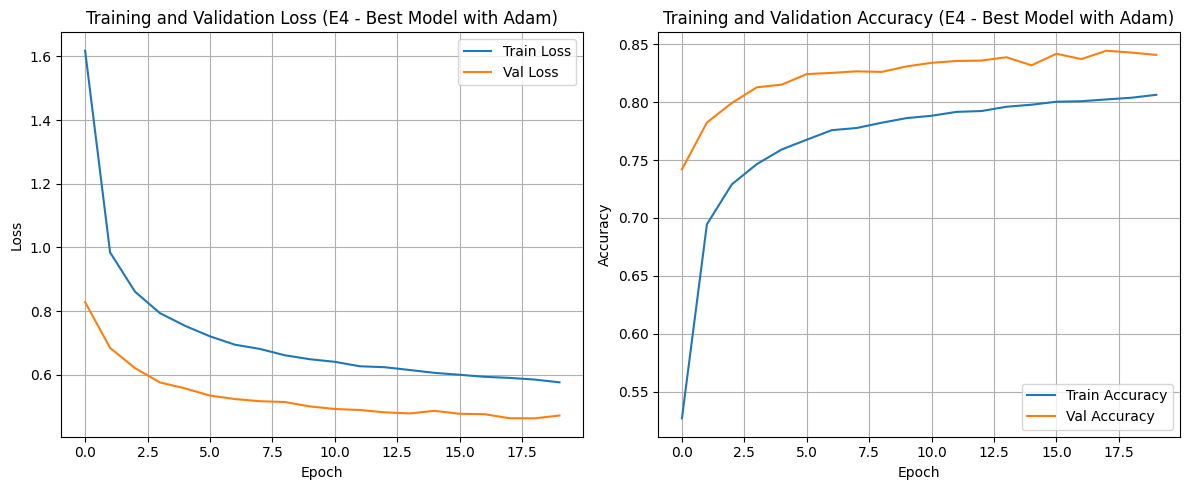

График сохранен в artifacts\figures\curves_best.png


In [17]:
# ### График для лучшей модели (E4)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_e4['train_loss'], label='Train Loss')
plt.plot(history_e4['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (E4 - Best Model with Adam)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_e4['train_acc'], label='Train Accuracy')
plt.plot(history_e4['val_acc'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy (E4 - Best Model with Adam)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'curves_best.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"График сохранен в {FIGURES_DIR / 'curves_best.png'}")

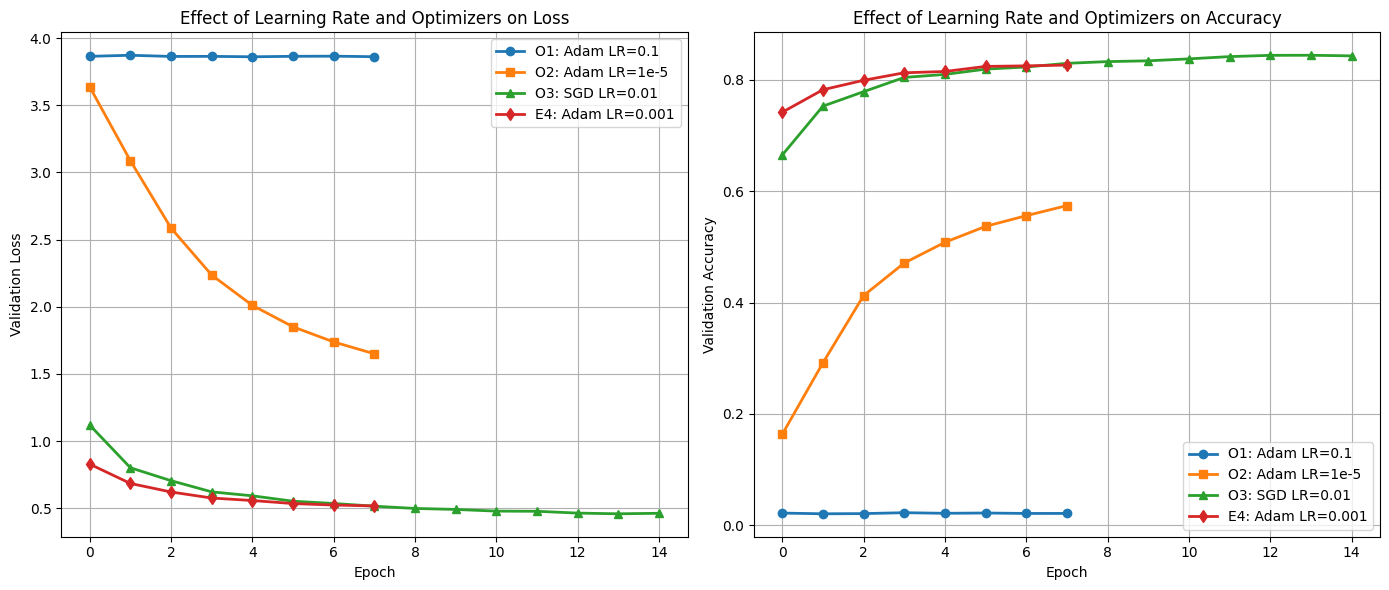

График сохранен в artifacts\figures\curves_lr_extremes.png


In [18]:
# ### График для экстремальных LR (O1 и O2 с Adam, O3 с SGD)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history_o1['val_loss'], label='O1: Adam LR=0.1', marker='o', linewidth=2)
plt.plot(history_o2['val_loss'], label='O2: Adam LR=1e-5', marker='s', linewidth=2)
plt.plot(history_o3['val_loss'], label='O3: SGD LR=0.01', marker='^', linewidth=2)
plt.plot(history_e4['val_loss'][:8], label='E4: Adam LR=0.001', marker='d', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Effect of Learning Rate and Optimizers on Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_o1['val_acc'], label='O1: Adam LR=0.1', marker='o', linewidth=2)
plt.plot(history_o2['val_acc'], label='O2: Adam LR=1e-5', marker='s', linewidth=2)
plt.plot(history_o3['val_acc'], label='O3: SGD LR=0.01', marker='^', linewidth=2)
plt.plot(history_e4['val_acc'][:8], label='E4: Adam LR=0.001', marker='d', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Effect of Learning Rate and Optimizers on Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'curves_lr_extremes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"График сохранен в {FIGURES_DIR / 'curves_lr_extremes.png'}")

In [19]:
# Создаем сводную таблицу
print("\n" + "="*50)
print("Сводная таблица результатов")
print("="*50)

print(df_results[['experiment_id', 'optimizer', 'lr', 'momentum', 'weight_decay', 
                  'best_val_accuracy', 'best_val_loss', 'epochs_trained']].to_string(index=False))

print("\n" + "="*50)
print("Выводы по оптимизаторам:")
print("="*50)
print("1. Adam (lr=0.001) показал лучшую сходимость и финальную точность")
print("2. Слишком большой LR (0.1) с Adam приводит к нестабильности и низкой точности")
print("3. Слишком маленький LR (1e-5) с Adam практически не обучает модель")
print("4. SGD с momentum и weight decay показывает стабильную, но более медленную сходимость")
print(f"\nЛучшая модель (E4 с Adam) показала точность на тесте: {test_accuracy:.4f}")


Сводная таблица результатов
experiment_id optimizer      lr  momentum  weight_decay  best_val_accuracy  best_val_loss  epochs_trained
           E1      Adam 0.00100       0.0        0.0000           0.844898       0.626386              20
           E2      Adam 0.00100       0.0        0.0000           0.844456       0.471557              20
           E3      Adam 0.00100       0.0        0.0000           0.855358       0.564667              20
           E4      Adam 0.00100       0.0        0.0000           0.844456       0.471557              20
           O1      Adam 0.10000       0.0        0.0000           0.022687       3.861931               8
           O2      Adam 0.00001       0.0        0.0000           0.574285       1.649494               8
           O3       SGD 0.01000       0.9        0.0001           0.844324       0.461895              15

Выводы по оптимизаторам:
1. Adam (lr=0.001) показал лучшую сходимость и финальную точность
2. Слишком большой LR (0.1) с A